# Optimización Bajo Incertidumbre (IIND 4125)

## Proyecto 3: Decisiones Secuenciales — MDP, Políticas y Aprendizaje

#### Objetivo: Tomar decisiones adaptativas en el tiempo mientras evolucionan fallas, demanda y generación

## 1. Punto de Partida: Reformulación Secuencial


| Elemento | Símbolo | Definición en el problema de resiliencia eléctrica |
|---|---|---|
| **Estado** | $S_t$ | Estado de la red eléctrica en el periodo $t$: capacidades disponibles de los arcos, arcos reforzados, arcos fallados, generación disponible, demanda nodal, déficit acumulado, presupuesto restante y régimen del sistema (Mediocristan o Extremistan). |
| **Decisión** | $x_t$ | Decisiones operativas y de inversión tomadas en el periodo $t$: reforzar arcos, reparar infraestructura, redistribuir flujo eléctrico y gestionar generación y déficit. |
| **Información exógena** | $W_{t+1}$ | Información incierta observada al pasar al periodo $t+1$: demanda eléctrica, disponibilidad de generación, fallas en líneas, reducción de capacidad, shocks extremos y ocurrencia de crisis sistémicas. |
| **Función de transición** | $S^M$ | Evolución de la red después de aplicar decisiones y observar incertidumbre. Las capacidades, disponibilidad y déficit se actualizan dinámicamente según las acciones tomadas y los shocks del entorno. |
| **Función de costo** | $C_t$ | Costo total del periodo: costos de operación de flujo, penalización por demanda no servida, costos de refuerzo y costos de reparación de infraestructura. |

### Función de transición

$S_{t+1} = S^M(S_t, x_t, W_{t+1})$

Por ejemplo, la capacidad de un arco puede evolucionar como:


$U_{e,t+1}=U_{e,t}$ $+\Delta U_e h_{e,t}-\text{fallas}_{e,t+1}$

donde:

- $h_{e,t}$ indica si el arco es reforzado,
- $\Delta U_e$ representa el incremento de capacidad,
- $\text{fallas}_{e,t+1}$ modela pérdidas de capacidad debidas a eventos extremos.

### Función de costo

$C_t =
\sum_{e \in E} c_e f_{e,t}
+
\pi \sum_{i \in L} \delta_{i,t}
+
\sum_{e \in E} H_e h_{e,t}
+
\sum_{e \in E} R_e r_{e,t}$


donde:

- $f_{e,t}$: flujo enviado por el arco $e$,
- $\delta_{i,t}$: demanda no servida,
- $h_{e,t}$: decisión de refuerzo,
- $r_{e,t}$: decisión de reparación,
- $\pi$: penalización por déficit.

## 2. Ambiente de Simulación



### 2.1 Generador de Variables Aleatorias

Función `generate_W(T, seed, mode)` que produce una secuencia temporal de información exógena para un episodio de $T$ periodos.

- **`mode='mediocristan'`**: ruido moderado, distribuciones clásicas (coherente con Proyecto 1).
- **`mode='extremistan'`**: colas pesadas, cambios de régimen, shocks (coherente con Proyecto 1).
- La semilla (`seed`) debe garantizar reproducibilidad.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from scenarios_utils import load_edges_from_csv, load_nodes_from_csv

INSTANCE = 69

edges = load_edges_from_csv("edges.csv")
nodes_all = load_nodes_from_csv("nodes.csv")

nodes = nodes_all[nodes_all["instance"] == INSTANCE].reset_index(drop=True)

print("Instancia:", INSTANCE)
print("Nodos:", len(nodes))
print("Arcos:", len(edges))

Instancia: 69
Nodos: 118
Arcos: 179


In [4]:
INSTANCE = 69


edges = load_edges_from_csv("edges.csv")
nodes = load_nodes_from_csv("nodes.csv")

nodes = nodes[nodes["instance"] == INSTANCE].reset_index(drop=True)

## Generación de Escenarios

En cada periodo $t$, el escenario generado incluye:

- demanda nodal,
- capacidad efectiva de transmisión,
- disponibilidad de generación,
- costos operativos,
- ocurrencia de crisis,
- fallas correlacionadas de infraestructura.

In [5]:
def generate_dynamic_scenarios(
    nodes,
    edges,
    T=10,
    n_paths=100,
    seed=123,
    p_crisis=0.10,
    dem_sigma=0.10,
    cost_sigma=0.05,
    crisis_dem_mult=2.0,
    crisis_cost_mult=2.0,
    p_outage=0.02,
    crisis_p_outage=0.20,
    cap_drop=0.70
):
    """
    Genera trayectorias dinámicas W_1, ..., W_T. Cada T es un periodo
    y cada W_t tiene TODA la información del problema.  
    """

    rng = np.random.default_rng(seed)

    rows_D = []
    rows_U = []
    rows_c = []
    rows_G = []
    rows_info = []

    for path in range(n_paths):

        for t in range(1, T + 1):

            crisis = rng.random() < p_crisis

            # Multiplicadores por régimen
            if crisis:
                dem_mult = rng.lognormal(mean=np.log(crisis_dem_mult), sigma=0.25)
                cost_mult = crisis_cost_mult
                outage_prob = crisis_p_outage
            else:
                dem_mult = max(rng.normal(1.0, dem_sigma), 0.0)
                cost_mult = max(rng.normal(1.0, cost_sigma), 0.1)
                outage_prob = p_outage

            # Demanda y generación
            for _, r in nodes.iterrows():

                node = int(r["node"])
                d_base = float(r.get("d", 0.0))
                g_base = float(r.get("p_max", 0.0)) if bool(r.get("is_generator", False)) else 0.0

                rows_D.append({
                    "path": path,
                    "t": t,
                    "node": node,
                    "D_it": d_base * dem_mult
                })

                rows_G.append({
                    "path": path,
                    "t": t,
                    "node": node,
                    "G_it": g_base * max(rng.normal(1.0, 0.05), 0.0)
                })

            # Capacidad y costos de arcos
            for _, r in edges.iterrows():

                e = int(r["e_id"])
                U_base = float(r.get("U_base", r.get("f_max", 100.0)))
                c_base = float(r.get("c_base", 1.0))

                failed = rng.random() < outage_prob
                U_mult = cap_drop if failed else 1.0

                rows_U.append({
                    "path": path,
                    "t": t,
                    "e_id": e,
                    "U_et": U_base * U_mult,
                    "failed": failed
                })

                rows_c.append({
                    "path": path,
                    "t": t,
                    "e_id": e,
                    "c_et": c_base * cost_mult
                })

            rows_info.append({
                "path": path,
                "t": t,
                "crisis": crisis,
                "dem_mult": dem_mult,
                "cost_mult": cost_mult
            })

    dfD_dyn = pd.DataFrame(rows_D)
    dfU_dyn = pd.DataFrame(rows_U)
    dfc_dyn = pd.DataFrame(rows_c)
    dfG_dyn = pd.DataFrame(rows_G)
    df_info_dyn = pd.DataFrame(rows_info)

    return dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn

In [6]:
dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn = generate_dynamic_scenarios(
    nodes=nodes,
    edges=edges,
    T=12,
    n_paths=10,
    seed=2026,
    p_crisis=0.15
)

df_info_dyn

,path,t,crisis,dem_mult,cost_mult
0,0,1,False,1.024057,0.905184
1,0,2,False,0.907642,1.024866
2,0,3,False,1.022961,1.005959
3,0,4,False,1.126639,1.028948
4,0,5,False,0.929139,0.987031
...,...,...,...,...,...
115,9,8,True,1.942448,2.000000
116,9,9,False,1.135964,0.980327
117,9,10,False,0.935621,1.039128
118,9,11,False,1.045840,0.994056


A diferencia de los proyectos anteriores, donde las decisiones de inversión se tomaban una sola vez sobre un conjunto fijo de escenarios, ahora la red evoluciona dinámicamente a través del tiempo. 

Para ello se definieron explícitamente los cinco elementos fundamentales del modelo: 
- el estado del sistema, 
- las decisiones de control, 
- la información exógena incierta, 
- la función de transición y 
- la función de costo. 

Además, los generadores de incertidumbre previamente desarrollados para Mediocristan y Extremistan fueron extendidos para producir secuencias temporales de shocks, permitiendo modelar eventos extremos, fallas de infraestructura y variaciones de demanda a lo largo de múltiples periodos. Esta reformulación permite estudiar políticas adaptativas y evaluar cómo diferentes estrategias de operación e inversión responden dinámicamente frente a escenarios normales y extremos.


In [7]:
def get_exogenous_info(path, t, dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn):
    """
    Extrae la información exógena W_{t+1} para un path y periodo dado.
    """

    D_t = (
        dfD_dyn[(dfD_dyn["path"] == path) & (dfD_dyn["t"] == t)]
        .set_index("node")["D_it"]
        .to_dict()
    )

    U_t = (
        dfU_dyn[(dfU_dyn["path"] == path) & (dfU_dyn["t"] == t)]
        .set_index("e_id")["U_et"]
        .to_dict()
    )

    failed_t = (
        dfU_dyn[(dfU_dyn["path"] == path) & (dfU_dyn["t"] == t)]
        .set_index("e_id")["failed"]
        .astype(int)
        .to_dict()
    )

    c_t = (
        dfc_dyn[(dfc_dyn["path"] == path) & (dfc_dyn["t"] == t)]
        .set_index("e_id")["c_et"]
        .to_dict()
    )

    G_t = (
        dfG_dyn[(dfG_dyn["path"] == path) & (dfG_dyn["t"] == t)]
        .set_index("node")["G_it"]
        .to_dict()
    )

    info_row = df_info_dyn[
        (df_info_dyn["path"] == path) & (df_info_dyn["t"] == t)
    ].iloc[0]

    W = {
        "D": D_t,
        "U": U_t,
        "failed": failed_t,
        "c": c_t,
        "G": G_t,
        "crisis": bool(info_row["crisis"]),
        "dem_mult": float(info_row["dem_mult"]),
        "cost_mult": float(info_row["cost_mult"])
    }

    return W

### 2.2 Función de Costo

Esta función captura simultáneamente los costos de operación, los costos de reforzamiento y reparación de infraestructura, y las penalizaciones asociadas a demanda no servida.

La contribución del periodo $t$ se modela como:

$C_t(S_t,x_t,W_{t+1})=$
$\underbrace{\sum_{e\in E} c_{e,t} f_{e,t}}_{\text{Costo operativo}}$
$+\underbrace{\pi \sum_{i\in N}\delta_{i,t}}_{\text{Penalización por déficit}}+$
$\underbrace{\sum_{e\in E} H_e r_{e,t}}_{\text{Costo de refuerzo}}+$
$\underbrace{\sum_{e\in E} R_e a_{e,t}}_{\text{Costo de reparación}}$

donde:

- $c_{e,t}$: costo operativo del arco $e$,
- $f_{e,t}$: flujo de energía transportado,
- $\delta_{i,t}$: demanda no servida en el nodo $i$,
- $\pi$: penalización unitaria por déficit,
- $H_e$: costo de reforzar el arco $e$,
- $r_{e,t}\in\{0,1\}$: decisión de reforzamiento,
- $R_e$: costo de reparación,
- $a_{e,t}\in\{0,1\}$: decisión de reparación.

---

### Objetivo dinámico total

El objetivo global del problema consiste en minimizar el costo esperado acumulado a lo largo del horizonte temporal:

$
\min
\mathbb{E}
\left[
\sum_{t=1}^{T} C_t
\right]
$


In [8]:
def compute_period_cost(
    state,
    action,
    W,
    operating_result,
    H_e,
    repair_cost=25.0,
    pi=190.0
):
    """
    Calcula el costo C_t del periodo.
    """

    reinforcement_cost = sum(
        H_e[e] * action["reinforce"].get(e, 0)
        for e in H_e
        if state["reinforced"].get(e, 0) == 0
    )

    repair_cost_total = repair_cost * sum(
        action["repair"].get(e, 0)
        for e in H_e
    )

    operating_cost = operating_result.get("operating_cost", 0.0)

    deficit_cost = pi * operating_result.get("total_deficit", 0.0)

    total_cost = (
        reinforcement_cost
        + repair_cost_total
        + operating_cost
        + deficit_cost
    )

    return {
        "total_cost": total_cost,
        "reinforcement_cost": reinforcement_cost,
        "repair_cost": repair_cost_total,
        "operating_cost": operating_cost,
        "deficit_cost": deficit_cost
    }

In [9]:
def simple_operating_model(state, action, W):

    total_demand = sum(W["D"].values())
    total_generation = sum(W["G"].values())

    served = min(total_demand, total_generation)
    deficit = max(total_demand - total_generation, 0.0)

    operating_cost = 0.0

    return {
        "served_demand": served,
        "total_deficit": deficit,
        "operating_cost": operating_cost
    }

In [10]:
def validate_operational_decisions(state, action, W, nodes, edges):
    """
    Valida y ajusta las decisiones operativas:
    - flujo no negativo
    - flujo <= capacidad
    - generación no negativa
    - generación despachada <= generación disponible
    """

    edges_list = edges["e_id"].astype(int).tolist()
    nodes_list = nodes["node"].astype(int).tolist()

    flow = {}
    generation_dispatch = {}

    for e in edges_list:
        f_e = float(action.get("flow", {}).get(e, 0.0))
        cap_e = max(float(state["capacity"].get(e, 0.0)), 0.0)

        # Si el arco está fallado, su flujo permitido es cero
        if state["failed"].get(e, 0) == 1:
            cap_e = 0.0

        flow[e] = min(max(f_e, 0.0), cap_e)

    for i in nodes_list:
        g_i = float(action.get("generation_dispatch", {}).get(i, 0.0))
        G_i = max(float(W["G"].get(i, 0.0)), 0.0)

        generation_dispatch[i] = min(max(g_i, 0.0), G_i)

    return flow, generation_dispatch

In [11]:
def operating_model_from_action(state, action, W, nodes, edges):
    """
    Evalúa la operación dada por la acción:
    - usa action["flow"] como flujo por arco
    - usa action["generation_dispatch"] como generación despachada

    Calcula déficit por balance nodal.
    """

    nodes_list = nodes["node"].astype(int).tolist()
    edges_list = edges["e_id"].astype(int).tolist()

    in_arcs = {
        int(i): edges.loc[edges["j"] == i, "e_id"].astype(int).tolist()
        for i in nodes_list
    }

    out_arcs = {
        int(i): edges.loc[edges["i"] == i, "e_id"].astype(int).tolist()
        for i in nodes_list
    }

    flow, generation_dispatch = validate_operational_decisions(
        state=state,
        action=action,
        W=W,
        nodes=nodes,
        edges=edges
    )

    delta = {}
    served_by_node = {}

    for i in nodes_list:
        demand_i = max(float(W["D"].get(i, 0.0)), 0.0)

        inflow_i = sum(flow[e] for e in in_arcs.get(i, []))
        outflow_i = sum(flow[e] for e in out_arcs.get(i, []))
        gen_i = generation_dispatch.get(i, 0.0)

        available_i = gen_i + inflow_i - outflow_i

        served_i = min(demand_i, max(available_i, 0.0))
        deficit_i = max(demand_i - served_i, 0.0)

        served_by_node[i] = served_i
        delta[i] = deficit_i

    operating_cost = sum(
        W["c"].get(e, 0.0) * flow[e]
        for e in edges_list
    )

    total_demand = sum(max(float(W["D"].get(i, 0.0)), 0.0) for i in nodes_list)
    total_deficit = sum(delta.values())
    served_demand = total_demand - total_deficit

    return {
        "served_demand": served_demand,
        "total_deficit": total_deficit,
        "operating_cost": operating_cost,
        "flow": flow,
        "generation_dispatch": generation_dispatch,
        "delta": delta,
        "served_by_node": served_by_node
    }

### 2.3 Función de Transición

In [12]:
def initialize_state(nodes, edges, budget=2000.0):
    """
    Crea el estado inicial S_0 de la red.
    """

    state = {
        "t": 0,
        "budget_remaining": float(budget),

        "reinforced": {
            int(e): 0 for e in edges["e_id"]
        },

        "capacity": {
            int(r["e_id"]): float(r.get("U_base", r.get("f_max", 100.0)))
            for _, r in edges.iterrows()
        },

        "failed": {
            int(e): 0 for e in edges["e_id"]
        },

        "flow": {
            int(e): 0.0 for e in edges["e_id"]
        },

        "generation_dispatch": {
            int(r["node"]): 0.0 for _, r in nodes.iterrows()
        },

        "cumulative_deficit": 0.0,
        "cumulative_cost": 0.0,

        "demand": {
            int(r["node"]): float(r.get("d", 0.0))
            for _, r in nodes.iterrows()
        },

        "generation_available": {
            int(r["node"]): float(r.get("p_max", 0.0)) if bool(r.get("is_generator", False)) else 0.0
            for _, r in nodes.iterrows()
        },

        "crisis": False
    }

    return state

In [13]:
def transition(
    state,
    action,
    W,
    nodes,
    edges,
    H_e,
    delta_u=0.8,
    budget_floor=0.0,
    repair_cost=25.0,
    pi=190.0
):
    """
    Transición determinista:
    S_{t+1} = S^M(S_t, x_t, W_{t+1})

    Acción:
    x_t = {
        "reinforce": refuerzo de arcos,
        "repair": reparación de arcos,
        "flow": flujo por arco,
        "generation_dispatch": generación despachada por nodo
    }
    """

    next_state = state.copy()

    next_state["reinforced"] = state["reinforced"].copy()
    next_state["capacity"] = state["capacity"].copy()
    next_state["failed"] = state["failed"].copy()

    next_state["demand"] = W["D"].copy()
    next_state["generation_available"] = W["G"].copy()

    # --------------------------------------------------------
    # 1. Aplicar refuerzo
    # --------------------------------------------------------

    for e, reinforce_decision in action["reinforce"].items():

        if reinforce_decision == 1 and next_state["reinforced"].get(e, 0) == 0:

            cost_e = H_e[e]

            if next_state["budget_remaining"] - cost_e >= budget_floor:

                next_state["reinforced"][e] = 1

    # --------------------------------------------------------
    # 2. Aplicar reparación
    # --------------------------------------------------------

    for e, repair_decision in action["repair"].items():

        if repair_decision == 1:

            if next_state["budget_remaining"] - repair_cost >= budget_floor:

                next_state["failed"][e] = 0

    # --------------------------------------------------------
    # 3. Aplicar fallas exógenas y actualizar capacidades
    # --------------------------------------------------------

    for e in next_state["capacity"].keys():

        failed_e = W["failed"].get(e, 0)

        if failed_e == 1:
            next_state["failed"][e] = 1
        else:
            if next_state["failed"].get(e, 0) != 1:
                next_state["failed"][e] = 0

        cap_exog = max(float(W["U"].get(e, 0.0)), 0.0)

        if next_state["failed"].get(e, 0) == 1:
            next_state["capacity"][e] = 0.0
        else:
            if next_state["reinforced"].get(e, 0) == 1:
                next_state["capacity"][e] = cap_exog * (1.0 + delta_u)
            else:
                next_state["capacity"][e] = cap_exog

    # --------------------------------------------------------
    # 4. Evaluar decisiones de flujo y generación
    # --------------------------------------------------------

    operating_result = operating_model_from_action(
        state=next_state,
        action=action,
        W=W,
        nodes=nodes,
        edges=edges
    )

    next_state["flow"] = operating_result["flow"]
    next_state["generation_dispatch"] = operating_result["generation_dispatch"]

    # --------------------------------------------------------
    # 5. Calcular costo
    # --------------------------------------------------------

    cost_breakdown = compute_period_cost(
        state=state,
        action=action,
        W=W,
        operating_result=operating_result,
        H_e=H_e,
        repair_cost=repair_cost,
        pi=pi
    )

    # --------------------------------------------------------
    # 6. Actualizar presupuesto
    # --------------------------------------------------------

    next_state["budget_remaining"] = max(
        next_state["budget_remaining"]
        - cost_breakdown["reinforcement_cost"]
        - cost_breakdown["repair_cost"],
        budget_floor
    )

    # --------------------------------------------------------
    # 7. Actualizar acumulados
    # --------------------------------------------------------

    next_state["cumulative_deficit"] = (
        state["cumulative_deficit"]
        + operating_result["total_deficit"]
    )

    next_state["cumulative_cost"] = (
        state["cumulative_cost"]
        + cost_breakdown["total_cost"]
    )

    next_state["crisis"] = W["crisis"]
    next_state["t"] = state["t"] + 1

    info = {
        "operating_result": operating_result,
        "cost_breakdown": cost_breakdown,
        "num_failed_edges": sum(next_state["failed"].values()),
        "num_reinforced_edges": sum(next_state["reinforced"].values()),
        "total_flow": sum(operating_result["flow"].values()),
        "total_generation_dispatch": sum(operating_result["generation_dispatch"].values())
    }

    return next_state, info

PRUEBA

O sea, ese código no corre todo el horizonte, sino solo un paso temporal para verificar que la función de transición funciona correctamente. (para eso se define un t de los que hay (12) en los df)

In [14]:
# Estado inicial
state = initialize_state(
    nodes=nodes,
    edges=edges,
    budget=2000.0
)

# Costos de refuerzo
H_e = {int(e): 50.0 for e in edges["e_id"]}

# Acción ejemplo: no reforzar, no reparar, no enviar flujo y no despachar generación
action = {
    "reinforce": {int(e): 0 for e in edges["e_id"]},
    "repair": {int(e): 0 for e in edges["e_id"]},
    "flow": {int(e): 0.0 for e in edges["e_id"]},
    "generation_dispatch": {int(i): 0.0 for i in nodes["node"]}
}

# Información exógena del path 0, periodo 1
W = get_exogenous_info(
    path=0,
    t=1,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn
)

# Transición
next_state, info = transition(
    state=state,
    action=action,
    W=W,
    nodes=nodes,
    edges=edges,
    H_e=H_e,
    delta_u=0.8,
    repair_cost=25.0,
    pi=190.0
)

info

{'operating_result': {'served_demand': 0.0,
  'total_deficit': 3323.815121589928,
  'operating_cost': 0.0,
  'flow': {0: 0.0,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.0,
   8: 0.0,
   9: 0.0,
   10: 0.0,
   11: 0.0,
   12: 0.0,
   13: 0.0,
   14: 0.0,
   15: 0.0,
   16: 0.0,
   17: 0.0,
   18: 0.0,
   19: 0.0,
   20: 0.0,
   21: 0.0,
   22: 0.0,
   23: 0.0,
   24: 0.0,
   25: 0.0,
   26: 0.0,
   27: 0.0,
   28: 0.0,
   29: 0.0,
   30: 0.0,
   31: 0.0,
   32: 0.0,
   33: 0.0,
   34: 0.0,
   35: 0.0,
   36: 0.0,
   37: 0.0,
   38: 0.0,
   39: 0.0,
   40: 0.0,
   41: 0.0,
   42: 0.0,
   43: 0.0,
   44: 0.0,
   45: 0.0,
   46: 0.0,
   47: 0.0,
   48: 0.0,
   49: 0.0,
   50: 0.0,
   51: 0.0,
   52: 0.0,
   53: 0.0,
   54: 0.0,
   55: 0.0,
   56: 0.0,
   57: 0.0,
   58: 0.0,
   59: 0.0,
   60: 0.0,
   61: 0.0,
   62: 0.0,
   63: 0.0,
   64: 0.0,
   65: 0.0,
   66: 0.0,
   67: 0.0,
   68: 0.0,
   69: 0.0,
   70: 0.0,
   71: 0.0,
   72: 0.0,
   73: 0.0,
   74: 

### 2.4 Simulador de Episodios

In [15]:
def run_episode(
    policy_fn,
    path,
    T,
    nodes,
    edges,
    dfD_dyn,
    dfU_dyn,
    dfc_dyn,
    dfG_dyn,
    df_info_dyn,
    H_e,
    budget=2000.0,
    delta_u=0.8,
    repair_cost=25.0,
    pi=190.0,
    policy_params=None
):
    """
    Ejecuta un episodio completo.
    """

    if policy_params is None:
        policy_params = {}

    state = initialize_state(
        nodes=nodes,
        edges=edges,
        budget=budget
    )

    history = []

    for t in range(1, T + 1):

        W = get_exogenous_info(
            path=path,
            t=t,
            dfD_dyn=dfD_dyn,
            dfU_dyn=dfU_dyn,
            dfc_dyn=dfc_dyn,
            dfG_dyn=dfG_dyn,
            df_info_dyn=df_info_dyn
        )

        action = policy_fn(
            state=state,
            W=W,
            nodes=nodes,
            edges=edges,
            H_e=H_e,
            params=policy_params
        )

        next_state, info = transition(
            state=state,
            action=action,
            W=W,
            nodes=nodes,
            edges=edges,
            H_e=H_e,
            delta_u=delta_u,
            repair_cost=repair_cost,
            pi=pi
        )

        history.append({
            "path": path,
            "t": t,
            "crisis": W["crisis"],
            "budget_remaining": next_state["budget_remaining"],
            "period_cost": info["cost_breakdown"]["total_cost"],
            "operating_cost": info["cost_breakdown"]["operating_cost"],
            "reinforcement_cost": info["cost_breakdown"]["reinforcement_cost"],
            "repair_cost": info["cost_breakdown"]["repair_cost"],
            "deficit_cost": info["cost_breakdown"]["deficit_cost"],
            "total_deficit": info["operating_result"]["total_deficit"],
            "served_demand": info["operating_result"]["served_demand"],
            "total_flow": info["total_flow"],
            "total_generation_dispatch": info["total_generation_dispatch"],
            "num_failed_edges": info["num_failed_edges"],
            "num_reinforced_edges": info["num_reinforced_edges"],
            "action_reinforce": [
                e for e, v in action["reinforce"].items() if v == 1
            ],
            "action_repair": [
                e for e, v in action["repair"].items() if v == 1
            ],
            "cumulative_cost": next_state["cumulative_cost"],
            "cumulative_deficit": next_state["cumulative_deficit"]
        })

        state = next_state

    return pd.DataFrame(history)

Ejemplo de política simple para probar:

In [16]:
def no_action_policy(state, W, nodes, edges, H_e, params=None):
    """
    Política base:
    - no refuerza
    - no repara
    - no envía flujo
    - no despacha generación
    """

    return {
        "reinforce": {int(e): 0 for e in edges["e_id"]},
        "repair": {int(e): 0 for e in edges["e_id"]},
        "flow": {int(e): 0.0 for e in edges["e_id"]},
        "generation_dispatch": {
            int(i): 0.0 for i in nodes["node"]
        }
    }

In [17]:
H_e = {int(e): 50.0 for e in edges["e_id"]}

episode_df = run_episode(
    policy_fn=no_action_policy,
    path=0,
    T=12,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0
)

episode_df

,path,t,crisis,budget_remaining,period_cost,operating_cost,reinforcement_cost,repair_cost,deficit_cost,total_deficit,served_demand,total_flow,total_generation_dispatch,num_failed_edges,num_reinforced_edges,action_reinforce,action_repair,cumulative_cost,cumulative_deficit
0,0,1,False,2000.0,6.315249e+05,0.0,0.0,0.0,6.315249e+05,3323.815122,0.0,0.0,0.0,4,0,[],[],6.315249e+05,3323.815122
1,0,2,False,2000.0,5.597331e+05,0.0,0.0,0.0,5.597331e+05,2945.963794,0.0,0.0,0.0,6,0,[],[],1.191258e+06,6269.778916
2,0,3,False,2000.0,6.308491e+05,0.0,0.0,0.0,6.308491e+05,3320.258167,0.0,0.0,0.0,9,0,[],[],1.822107e+06,9590.037083
3,0,4,False,2000.0,6.947863e+05,0.0,0.0,0.0,6.947863e+05,3656.769875,0.0,0.0,0.0,13,0,[],[],2.516893e+06,13246.806958
4,0,5,False,2000.0,5.729898e+05,0.0,0.0,0.0,5.729898e+05,3015.735701,0.0,0.0,0.0,14,0,[],[],3.089883e+06,16262.542659
5,0,6,True,2000.0,1.539002e+06,0.0,0.0,0.0,1.539002e+06,8100.011914,0.0,0.0,0.0,47,0,[],[],4.628885e+06,24362.554573
6,0,7,False,2000.0,7.010267e+05,0.0,0.0,0.0,7.010267e+05,3689.613952,0.0,0.0,0.0,50,0,[],[],5.329912e+06,28052.168525
7,0,8,False,2000.0,5.441394e+05,0.0,0.0,0.0,5.441394e+05,2863.891538,0.0,0.0,0.0,53,0,[],[],5.874051e+06,30916.060064
8,0,9,False,2000.0,5.396924e+05,0.0,0.0,0.0,5.396924e+05,2840.486167,0.0,0.0,0.0,58,0,[],[],6.413744e+06,33756.546231
9,0,10,False,2000.0,6.505805e+05,0.0,0.0,0.0,6.505805e+05,3424.107815,0.0,0.0,0.0,59,0,[],[],7.064324e+06,37180.654046


Las decisiones operativas de flujo y despacho son propuestas directamente por la política y posteriormente validadas por el modelo físico simplificado de la red.

## 3. Políticas: Implementación y Comparación

### 3.2 VFA — Value Function Approximation 

#### Value Iteration (V.I)

In [18]:
def discretize_state(state):
    """
    Estado discreto para VI y Q-learning.
    """

    failed = sum(state["failed"].values())
    reinforced = sum(state["reinforced"].values())
    budget = state["budget_remaining"]
    deficit = state["cumulative_deficit"]
    crisis = int(state["crisis"])

    failed_bin = min(failed // 10, 5)
    reinforced_bin = min(reinforced // 5, 5)

    if budget > 1500:
        budget_bin = 2
    elif budget > 500:
        budget_bin = 1
    else:
        budget_bin = 0

    if deficit == 0:
        deficit_bin = 0
    elif deficit < 500:
        deficit_bin = 1
    else:
        deficit_bin = 2

    return (crisis, failed_bin, reinforced_bin, budget_bin, deficit_bin)

In [19]:
ACTION_NAMES = [
    "do_nothing",
    "repair_failed",
    "reinforce_low_capacity",
    "repair_and_reinforce"
]

In [20]:
def build_action(action_name, state, W, nodes, edges, H_e, max_edges=3):
    """
    Construye una acción completa con 4 decisiones:
    - reinforce
    - repair
    - flow
    - generation_dispatch
    """

    edges_list = edges["e_id"].astype(int).tolist()
    nodes_list = nodes["node"].astype(int).tolist()

    action = {
        "reinforce": {e: 0 for e in edges_list},
        "repair": {e: 0 for e in edges_list},
        "flow": {e: 0.0 for e in edges_list},
        "generation_dispatch": {i: 0.0 for i in nodes_list}
    }

    # Generación despachada: usa toda la generación disponible
    for i in nodes_list:
        action["generation_dispatch"][i] = W["G"].get(i, 0.0)

    # Flujo simple: permite flujo proporcional a capacidad disponible
    # Nota: la transición luego valida capacidad y no negatividad.
    for e in edges_list:
        if state["failed"].get(e, 0) == 0:
            action["flow"][e] = 0.25 * state["capacity"].get(e, 0.0)

    if action_name == "do_nothing":
        return action

    if action_name in ["repair_failed", "repair_and_reinforce"]:
        failed_edges = [
            e for e in edges_list
            if state["failed"].get(e, 0) == 1
        ]

        for e in failed_edges[:max_edges]:
            action["repair"][e] = 1

    if action_name in ["reinforce_low_capacity", "repair_and_reinforce"]:
        candidate_edges = [
            e for e in edges_list
            if state["reinforced"].get(e, 0) == 0
        ]

        candidate_edges = sorted(
            candidate_edges,
            key=lambda e: state["capacity"].get(e, 0.0)
        )

        for e in candidate_edges[:max_edges]:
            action["reinforce"][e] = 1

    return action

In [21]:
def representative_state_from_discrete(s_disc, nodes, edges, budget=2000.0):
    """
    Construye un estado continuo representativo para un estado discreto.
    """

    state = initialize_state(nodes, edges, budget=budget)

    crisis, failed_bin, reinforced_bin, budget_bin, deficit_bin = s_disc

    edges_list = edges["e_id"].astype(int).tolist()

    # Fallas representativas
    n_failed = failed_bin * 10
    for e in edges_list[:n_failed]:
        state["failed"][e] = 1
        state["capacity"][e] = 0.0

    # Refuerzos representativos
    n_reinforced = reinforced_bin * 5
    for e in edges_list[:n_reinforced]:
        state["reinforced"][e] = 1

    # Presupuesto representativo
    if budget_bin == 2:
        state["budget_remaining"] = 1800
    elif budget_bin == 1:
        state["budget_remaining"] = 1000
    else:
        state["budget_remaining"] = 200

    # Déficit representativo
    if deficit_bin == 0:
        state["cumulative_deficit"] = 0
    elif deficit_bin == 1:
        state["cumulative_deficit"] = 250
    else:
        state["cumulative_deficit"] = 1000

    state["crisis"] = bool(crisis)

    return state

In [23]:
def build_W_pool(dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn, n_samples=30):
    """
    Extrae una muestra de realizaciones W para aproximar esperanza en VI.
    """

    available = df_info_dyn[["path", "t"]].drop_duplicates().head(n_samples)

    W_pool = []

    for _, r in available.iterrows():
        W = get_exogenous_info(
            path=int(r["path"]),
            t=int(r["t"]),
            dfD_dyn=dfD_dyn,
            dfU_dyn=dfU_dyn,
            dfc_dyn=dfc_dyn,
            dfG_dyn=dfG_dyn,
            df_info_dyn=df_info_dyn
        )
        W_pool.append(W)

    return W_pool

### Q-Learning

In [1]:
def epsilon_greedy_action(Q, s, epsilon=0.10):
    """
    Selección epsilon-greedy.
    """

    if np.random.rand() < epsilon:
        return np.random.choice(ACTION_NAMES)

    values = [Q.get((s, a), 0.0) for a in ACTION_NAMES]
    return ACTION_NAMES[int(np.argmin(values))]

In [24]:
def q_learning_train(
    nodes,
    edges,
    H_e,
    dfD_dyn,
    dfU_dyn,
    dfc_dyn,
    dfG_dyn,
    df_info_dyn,
    T=12,
    n_episodes=300,
    alpha=0.10,
    gamma=0.95,
    epsilon=0.20,
    budget=2000.0,
    seed=123
):
    """
    Q-learning para minimizar costos.
    """

    rng = np.random.default_rng(seed)
    Q = {}

    episode_returns = []

    available_paths = df_info_dyn["path"].unique()

    for ep in range(n_episodes):
        print(f"Episode {ep+1}/{n_episodes}...")
        path = int(rng.choice(available_paths))

        state = initialize_state(
            nodes=nodes,
            edges=edges,
            budget=budget
        )

        total_return = 0.0

        for t in range(1, T + 1):

            W = get_exogenous_info(
                path=path,
                t=t,
                dfD_dyn=dfD_dyn,
                dfU_dyn=dfU_dyn,
                dfc_dyn=dfc_dyn,
                dfG_dyn=dfG_dyn,
                df_info_dyn=df_info_dyn
            )

            s = discretize_state(state)

            if rng.random() < epsilon:
                a_name = rng.choice(ACTION_NAMES)
            else:
                values = [Q.get((s, a), 0.0) for a in ACTION_NAMES]
                a_name = ACTION_NAMES[int(np.argmin(values))]

            action = build_action(
                action_name=a_name,
                state=state,
                W=W,
                nodes=nodes,
                edges=edges,
                H_e=H_e
            )

            next_state, info = transition(
                state=state,
                action=action,
                W=W,
                nodes=nodes,
                edges=edges,
                H_e=H_e
            )

            cost = info["cost_breakdown"]["total_cost"]
            total_return += cost

            s_next = discretize_state(next_state)

            best_next = min(
                Q.get((s_next, a_next), 0.0)
                for a_next in ACTION_NAMES
            )

            old_q = Q.get((s, a_name), 0.0)

            Q[(s, a_name)] = old_q + alpha * (
                cost + gamma * best_next - old_q
            )

            state = next_state

        episode_returns.append(total_return)

        if (ep + 1) % 25 == 0:
            print(f"Episode {ep+1}/{n_episodes} | return = {total_return:.2f}")

    return Q, episode_returns

In [ ]:
Q, q_returns = q_learning_train(
    nodes=nodes,
    edges=edges,
    H_e=H_e,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    T=12,
    n_episodes=1500,   # más episodios
    alpha=0.05,        # menor tasa de aprendizaje
    gamma=0.90,        # menos peso al futuro lejano
    epsilon=0.30,      # más exploración inicial
    budget=2000.0,
    seed=2026
)

Episode 1/300...
Episode 2/300...
Episode 3/300...
Episode 4/300...
Episode 5/300...
Episode 6/300...
Episode 7/300...
Episode 8/300...
Episode 9/300...
Episode 10/300...
Episode 11/300...
Episode 12/300...
Episode 13/300...
Episode 14/300...
Episode 15/300...
Episode 16/300...
Episode 17/300...
Episode 18/300...
Episode 19/300...
Episode 20/300...
Episode 21/300...
Episode 22/300...
Episode 23/300...
Episode 24/300...
Episode 25/300...
Episode 25/300 | return = 19271790.14
Episode 26/300...
Episode 27/300...
Episode 28/300...
Episode 29/300...
Episode 30/300...
Episode 31/300...
Episode 32/300...
Episode 33/300...
Episode 34/300...
Episode 35/300...
Episode 36/300...
Episode 37/300...
Episode 38/300...
Episode 39/300...
Episode 40/300...
Episode 41/300...
Episode 42/300...
Episode 43/300...
Episode 44/300...
Episode 45/300...
Episode 46/300...
Episode 47/300...
Episode 48/300...
Episode 49/300...
Episode 50/300...
Episode 50/300 | return = 20858778.81
Episode 51/300...
Episode 52/300.

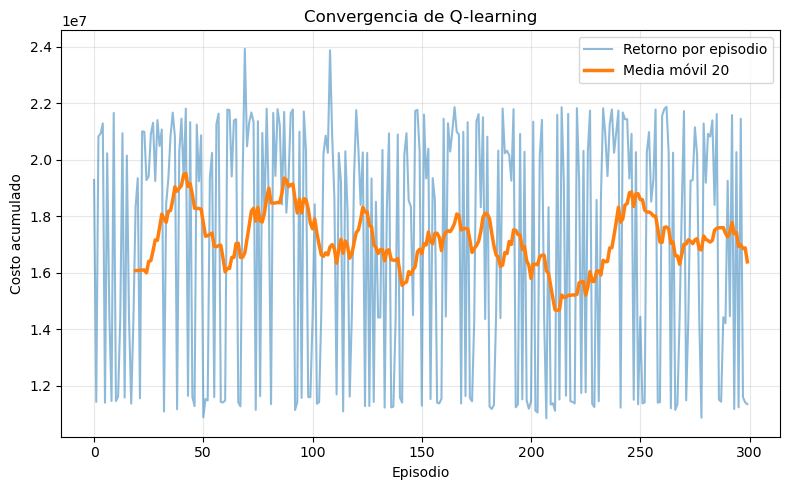

In [28]:
plt.figure(figsize=(8,5))
plt.plot(q_returns, alpha=0.5, label="Retorno por episodio")

window = 20
if len(q_returns) >= window:
    moving_avg = pd.Series(q_returns).rolling(window).mean()
    plt.plot(moving_avg, linewidth=2.5, label=f"Media móvil {window}")

plt.xlabel("Episodio")
plt.ylabel("Costo acumulado")
plt.title("Convergencia de Q-learning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
def q_learning_policy_fn(state, W, nodes, edges, H_e, params=None):
    """
    Política greedy a partir de Q-learning.
    """

    Q = params["Q"]

    s = discretize_state(state)

    values = [Q.get((s, a), 0.0) for a in ACTION_NAMES]
    best_action_name = ACTION_NAMES[int(np.argmin(values))]

    return build_action(
        action_name=best_action_name,
        state=state,
        W=W,
        nodes=nodes,
        edges=edges,
        H_e=H_e
    )

In [30]:
episode_q = run_episode(
    policy_fn=q_learning_policy_fn,
    path=0,
    T=12,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0,
    policy_params={"Q": Q}
)

episode_q

,path,t,crisis,budget_remaining,period_cost,operating_cost,reinforcement_cost,repair_cost,deficit_cost,total_deficit,served_demand,total_flow,total_generation_dispatch,num_failed_edges,num_reinforced_edges,action_reinforce,action_repair,cumulative_cost,cumulative_deficit
0,0,1,False,2000.0,1.527796e+06,1.067435e+06,0.0,0.0,4.603611e+05,2422.952983,900.862139,19746.75,7760.049336,4,0,[],[],1.527796e+06,2422.952983
1,0,2,False,1850.0,1.619714e+06,1.207131e+06,150.0,0.0,4.124329e+05,2170.699603,775.264191,19610.25,7628.866382,6,3,"[102, 139, 148]",[],3.147510e+06,4593.652586
2,0,3,False,1700.0,1.643169e+06,1.182357e+06,150.0,0.0,4.606616e+05,2424.534549,895.723618,19409.25,7597.748409,9,6,"[39, 57, 174]",[],4.790679e+06,7018.187136
3,0,4,False,1700.0,1.717281e+06,1.204746e+06,0.0,0.0,5.125351e+05,2697.553105,959.216770,19112.00,7641.660269,13,6,[],[],6.507960e+06,9715.740240
4,0,5,False,1625.0,1.571294e+06,1.155049e+06,0.0,75.0,4.161697e+05,2190.366590,825.369111,19033.00,7560.929300,11,6,[],"[31, 38, 39]",8.079253e+06,11906.106830
5,0,6,True,1550.0,3.342339e+06,2.234211e+06,0.0,75.0,1.108053e+06,5831.858349,2268.153566,16305.20,7686.697248,43,6,[],"[57, 76, 99]",1.142159e+07,17737.965179
6,0,7,False,1325.0,1.615292e+06,1.147061e+06,150.0,75.0,4.680060e+05,2463.189227,1226.424725,16164.95,7681.694526,43,9,"[0, 1, 7]","[0, 1, 7]",1.303688e+07,20201.154406
7,0,8,False,1325.0,1.400511e+06,1.043750e+06,0.0,0.0,3.567612e+05,1877.690543,986.200996,16771.70,7637.659839,46,9,[],[],1.443740e+07,22078.844949
8,0,9,False,1325.0,1.337493e+06,9.788193e+05,0.0,0.0,3.586741e+05,1887.758186,952.727981,15166.35,7865.551006,52,9,[],[],1.577489e+07,23966.603135
9,0,10,False,1325.0,1.504554e+06,1.065392e+06,0.0,0.0,4.391619e+05,2311.378172,1112.729643,15094.85,7583.248698,53,9,[],[],1.727944e+07,26277.981308


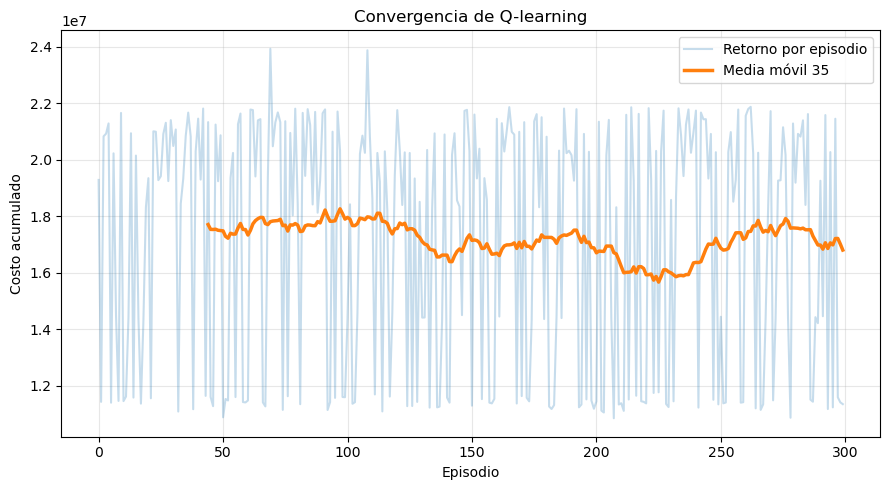

In [ ]:
plt.figure(figsize=(9,5))
plt.plot(q_returns, alpha=0.25, label="Retorno por episodio")

moving_avg = pd.Series(q_returns).rolling(45).mean()
plt.plot(moving_avg, linewidth=2.5, label="Media móvil 45")

plt.xlabel("Episodio")
plt.ylabel("Costo acumulado")
plt.title("Convergencia de Q-learning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
initial_avg = np.mean(q_returns[:50])
final_avg = np.mean(q_returns[-50:])

improvement = 100 * (initial_avg - final_avg) / initial_avg

print("Promedio inicial:", initial_avg)
print("Promedio final:", final_avg)
print("Mejora (%):", improvement)

Promedio inicial: 17613136.310225237
Promedio final: 16686361.156237239
Mejora (%): 5.26184058116874


In [32]:
# Política aprendida por estado discreto
policy_rows = []

for s in sorted(set([key[0] for key in Q.keys()])):
    values = {a: Q.get((s, a), 0.0) for a in ACTION_NAMES}
    best_action = min(values, key=values.get)

    policy_rows.append({
        "crisis": s[0],
        "failed_bin": s[1],
        "reinforced_bin": s[2],
        "budget_bin": s[3],
        "deficit_bin": s[4],
        "best_action": best_action,
        **values
    })

policy_df = pd.DataFrame(policy_rows)
policy_df.head()

,crisis,failed_bin,reinforced_bin,budget_bin,deficit_bin,best_action,do_nothing,repair_failed,reinforce_low_capacity,repair_and_reinforce
0,0,0,0,2,0,repair_failed,6.535821e+06,6.486595e+06,6.525449e+06,6.527461e+06
1,0,0,0,2,2,reinforce_low_capacity,5.811786e+06,6.047547e+06,5.730119e+06,5.834015e+06
2,0,0,1,1,2,do_nothing,3.183924e+06,3.344636e+06,3.309600e+06,3.262337e+06
3,0,0,1,2,2,do_nothing,4.276553e+06,4.460125e+06,4.314010e+06,4.307490e+06
4,0,0,2,1,2,reinforce_low_capacity,2.225111e+06,2.250270e+06,2.033839e+06,2.066079e+06


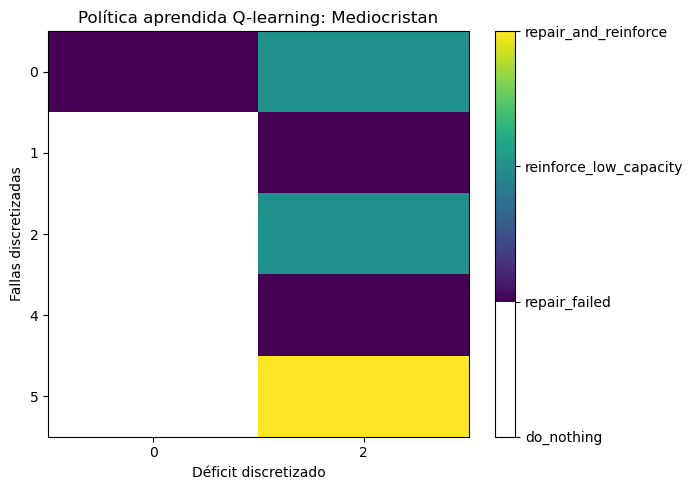

In [33]:
action_to_num = {a: i for i, a in enumerate(ACTION_NAMES)}

df_plot = policy_df.copy()
df_plot["action_num"] = df_plot["best_action"].map(action_to_num)

# Fijamos crisis=0, presupuesto alto, refuerzos bajos
subset = df_plot[
    (df_plot["crisis"] == 0) &
    (df_plot["budget_bin"] == 2) &
    (df_plot["reinforced_bin"] == 0)
]

pivot = subset.pivot_table(
    index="failed_bin",
    columns="deficit_bin",
    values="action_num",
    aggfunc="first"
)

plt.figure(figsize=(7,5))
plt.imshow(pivot, aspect="auto")

plt.xticks(
    ticks=np.arange(len(pivot.columns)),
    labels=pivot.columns
)
plt.yticks(
    ticks=np.arange(len(pivot.index)),
    labels=pivot.index
)

plt.xlabel("Déficit discretizado")
plt.ylabel("Fallas discretizadas")
plt.title("Política aprendida Q-learning: Mediocristan")

cbar = plt.colorbar()
cbar.set_ticks(list(action_to_num.values()))
cbar.set_ticklabels(list(action_to_num.keys()))

plt.tight_layout()
plt.show()

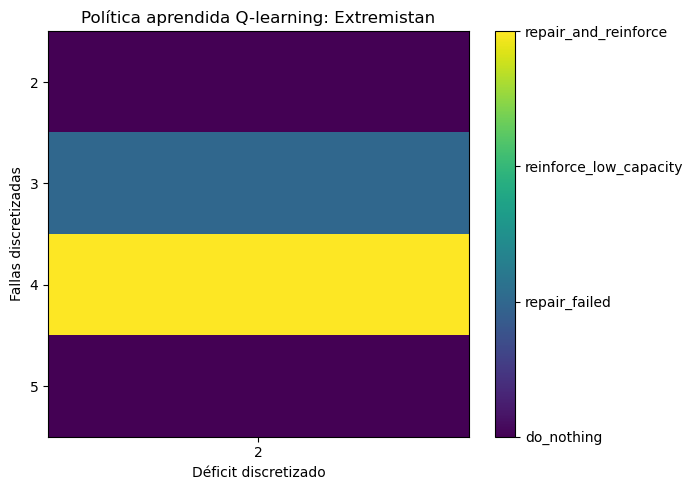

In [34]:
subset = df_plot[
    (df_plot["crisis"] == 1) &
    (df_plot["budget_bin"] == 2) &
    (df_plot["reinforced_bin"] == 0)
]

pivot = subset.pivot_table(
    index="failed_bin",
    columns="deficit_bin",
    values="action_num",
    aggfunc="first"
)

plt.figure(figsize=(7,5))
plt.imshow(pivot, aspect="auto")

plt.xticks(np.arange(len(pivot.columns)), pivot.columns)
plt.yticks(np.arange(len(pivot.index)), pivot.index)

plt.xlabel("Déficit discretizado")
plt.ylabel("Fallas discretizadas")
plt.title("Política aprendida Q-learning: Extremistan")

cbar = plt.colorbar()
cbar.set_ticks(list(action_to_num.values()))
cbar.set_ticklabels(list(action_to_num.keys()))

plt.tight_layout()
plt.show()